# Failure Predictor model with `sklearn`

In [1]:
from types import NoneType

import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.base import BaseEstimator
from sklearn.metrics import make_scorer, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from utils.ml import calculate_performance_metrics
import matplotlib.pyplot as plt
import joblib
import json
import warnings

warnings.filterwarnings("ignore", message=".*Setting penalty=None will ignore the C and l1_ratio parameters.*")
warnings.filterwarnings("ignore", message=".*The max_iter was reached.*")

In [2]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
model_file_path = "model_logreg_sklearn_failure.pkl"

In [3]:
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

In [4]:
# Load section data
section_data = config["section"]

section_variables = []
for p in section_data["params"].keys():
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        
load_components = ["n", "mxx", "myy", "vx", "vy", "mzz"]
predictor_columns = section_variables + load_components

In [5]:
df = pd.read_csv(data_file_path)
df = df.dropna()
assert df.isnull().sum().max() == 0, "DataFrame still contains NaN values after dropping."
print("Number of rows after dropping NaNs:", len(df))
df.head(100)

Number of rows after dropping NaNs: 3720


,d,b,t,r_out,n_r,n,mxx,myy,vx,vy,mzz,area,ixx,iyy,ixy,g_eff,utilization,section_param_id,section_type
0,292.940338,184.123599,16.722934,17.628862,4,-688877.841108,-1.312324e+07,2.412614e+06,-115170.575087,13682.531592,1.153415e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.322426,0,rectangular_hollow_section
1,292.940338,184.123599,16.722934,17.628862,4,354570.903962,-2.555486e+07,-5.432602e+06,41320.270385,152295.668465,-2.124411e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.352120,0,rectangular_hollow_section
2,292.940338,184.123599,16.722934,17.628862,4,-487911.441850,-6.665061e+06,2.604899e+07,-240323.071707,238398.799619,-1.857385e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.762931,0,rectangular_hollow_section
3,292.940338,184.123599,16.722934,17.628862,4,-48213.704668,2.253705e+07,1.034981e+07,-233498.377101,-168306.320838,1.210748e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.647851,0,rectangular_hollow_section
4,292.940338,184.123599,16.722934,17.628862,4,-957990.414679,-5.910821e+06,9.593818e+06,17546.913768,-174641.502762,1.074127e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.274913,0,rectangular_hollow_section
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,101.813572,109.591089,13.930502,10.252011,4,-564928.616997,1.622176e+07,2.614503e+07,175814.240826,-39441.351069,2.216032e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.077578,5,rectangular_hollow_section
116,101.813572,109.591089,13.930502,10.252011,4,-312441.445315,1.047845e+07,2.782598e+07,-214745.990821,29139.577702,-1.595956e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,0.945353,5,rectangular_hollow_section
117,101.813572,109.591089,13.930502,10.252011,4,160602.876633,1.547682e+07,-1.796579e+07,203558.739351,-52621.391867,-2.141584e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.166064,5,rectangular_hollow_section
118,101.813572,109.591089,13.930502,10.252011,4,-261612.747473,5.105223e+06,1.758743e+07,243210.142476,-234825.931062,-6.338786e+06,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.224112,5,rectangular_hollow_section


In [6]:
X = df[predictor_columns]
df["failure"] = df["utilization"] > 1.0
y = df[["failure"]]
X.shape, y.shape

((3720, 10), (3720, 1))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=df["failure"]
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2492, 10)
Testing data shape: (1228, 10)


In [8]:
models = {}


def add_model(name:str, model:BaseEstimator, grid:dict | NoneType = None) -> None:
    steps = [
        ("scaling", StandardScaler()),
        ("classification", model)
    ]
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train.values.ravel())
    models[name] = {"model": pipeline}
    if grid:
        models[name]["params_grid"] = grid
    

add_model(
    "LogReg", 
    LogisticRegression(solver='saga', max_iter=100), 
    {
        "classification__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "classification__penalty": ["l1", "l2", None],
    }
)

models

{'LogReg': {'model': Pipeline(steps=[('scaling', StandardScaler()),
                  ('classification', LogisticRegression(solver='saga'))]),
  'params_grid': {'classification__C': [0.001, 0.01, 0.1, 1, 10, 100],
   'classification__penalty': ['l1', 'l2', None]}}}

In [9]:
# Add model with engineered features
def add_engineered_features(df: pd.DataFrame, power:int=2) -> pd.DataFrame:
    df_new = df.copy()
    for c in predictor_columns:
        df_new[f"{c}_{power}"] = df[c] ** power
    return df_new


params_grid = {
    "classification__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classification__penalty": ["l1", "l2", None],
}

# ------ add model ----------------------------------------------------------------------

model_name = "LogReg 2"
steps = [
    ("feature_eng_2", FunctionTransformer(add_engineered_features, kw_args=dict(power=2))),
    ("scaling", StandardScaler()),
    ("classification", LogisticRegression(solver='saga', max_iter=100))
]
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train.values.ravel())
models[model_name] = {"model": pipeline}
models[model_name]["params_grid"] = params_grid

# ------ add model ----------------------------------------------------------------------

model_name = "LogReg 3"
steps = [
    ("feature_eng_2", FunctionTransformer(add_engineered_features, kw_args=dict(power=2))),
    ("feature_eng_3", FunctionTransformer(add_engineered_features, kw_args=dict(power=3))),
    ("scaling", StandardScaler()),
    ("classification", LogisticRegression(solver='saga', max_iter=100))
]
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train.values.ravel())
models[model_name] = {"model": pipeline}
models[model_name]["params_grid"] = params_grid

In [10]:
params_grid = {
    "classification__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classification__penalty": ["l1", "l2", None],
}

model_name = "LogReg Poly"
steps = [
    ("feature_eng", PolynomialFeatures(3, include_bias=False)),
    ("scaling", StandardScaler()),
    ("classification", LogisticRegression(solver='saga', max_iter=100))
]
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train.values.ravel())
models[model_name] = {"model": pipeline}
models[model_name]["params_grid"] = params_grid

In [11]:
def scorer(y_true:np.ndarray, y_pred:np.ndarray) -> float:
    cm = confusion_matrix(y_true, y_pred)
    metrics = calculate_performance_metrics(cm)
    score = 0.8 * metrics['NPV'] + 0.2 * metrics['PPV']
    return score


scoring_fnc = make_scorer(scorer)

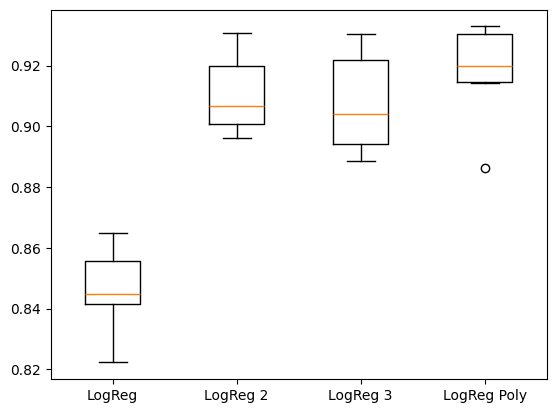

In [12]:
results = []
labels = []
for model_name in models:
  model = models[model_name]["model"]
  labels.append(model_name)
  
  # Define K-Fold cross-validation
  kf = StratifiedKFold(n_splits=6, random_state=42, shuffle=True)
  
  # Perform cross-validation
  cv_scores = cross_val_score(model, X_train, y_train.values.ravel(), cv=kf, scoring=scoring_fnc)
  
  # Append the results
  results.append(cv_scores)

# Create a box plot of the results
plt.boxplot(results, tick_labels=labels)
plt.show()

In [13]:
for model in models:
    if not "params_grid" in models[model]:
        continue

    kf = StratifiedKFold(n_splits=6, random_state=42, shuffle=True)
    param_grid = models[model]["params_grid"]
    cv = RandomizedSearchCV(models[model]["model"], param_grid, cv=kf, n_iter=10, scoring=scoring_fnc)
    cv.fit(X_train, y_train.values.ravel())

    models[model]["model"] = cv.best_estimator_

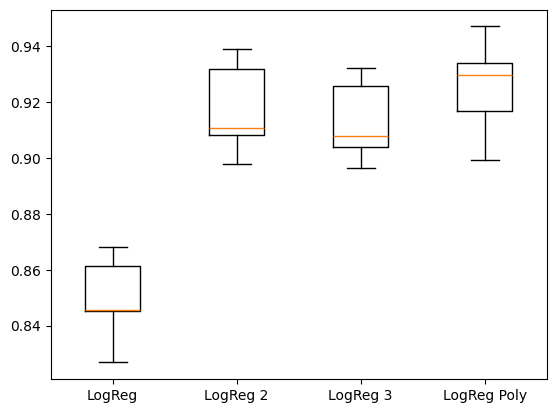

In [14]:
# perform cross validation on all the models for the box plot
results = []
labels = []
for model_name in models:
    model = models[model_name]["model"]
    labels.append(model_name)
    
    # Define K-Fold cross-validation
    kf = StratifiedKFold(n_splits=6, random_state=42, shuffle=True)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train.values.ravel(), cv=kf, scoring=scoring_fnc)
    
    # Append the results
    results.append(cv_scores)
    
    # Save the mean score
    models[model_name]["cv_mean"] = cv_scores.mean()

# Create a box plot of the results
plt.boxplot(results, tick_labels=labels)
plt.show()

In [15]:
best_model_name = max(models, key=lambda name: models[name].get("cv_mean", float('-inf')))
best_model = models[best_model_name]["model"]
print("Best model:", best_model_name)
best_model

Best model: LogReg Poly


,steps,"[('feature_eng', ...), ('scaling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


## Assess Classification Performance

Performance Metrics:
NPV: 0.9424
PPV: 0.9045


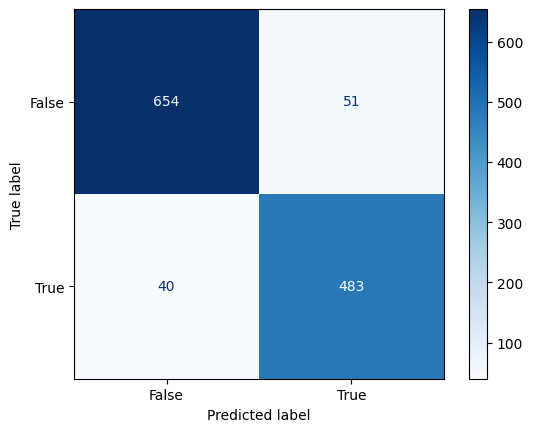

In [18]:
# Make predictions on the test data
y_pred = best_model.predict(X_test)

print("Performance Metrics:")
cm = confusion_matrix(y_test, y_pred)
metrics = calculate_performance_metrics(cm)
print("NPV: {:.4f}".format(metrics['NPV']))
print("PPV: {:.4f}".format(metrics['PPV']))

# (Optional) Display the confusion matrix as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')

## Save Model

In [17]:
with open(model_file_path, "wb") as f:
    joblib.dump(best_model, f, protocol=5)